In [2]:
%matplotlib inline
import torch
import random
from d2l import torch as d2l

In [3]:
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声。"""
    # 生成均值为0，方差为1的随机数作为特征 X
    X = torch.normal(0, 1, (num_examples, len(w)))
    
    # 计算 y = Xw + b
    y = torch.matmul(X, w) + b
    
    # 给 y 加上随机噪声 (均值为0，方差为0.01)
    y += torch.normal(0, 0.01, y.shape)
    
    # 返回 X 和 变形后的 y (确保它是列向量)
    return X, y.reshape((-1, 1))


In [4]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

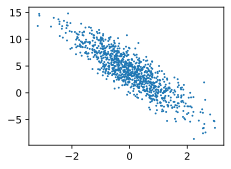

In [9]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

In [10]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [13]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.3375,  1.3046],
        [-1.0492, -0.0109],
        [-0.7672, -0.1179],
        [-1.3961,  0.6913],
        [ 1.0379, -0.2559],
        [-0.2667,  0.2407],
        [ 0.1765, -1.1293],
        [-0.0184, -0.6413],
        [-0.7094, -0.8762],
        [ 2.3282, -0.4002]]) 
 tensor([[ 2.4411],
        [ 2.1442],
        [ 3.0587],
        [-0.9370],
        [ 7.1460],
        [ 2.8508],
        [ 8.3877],
        [ 6.3352],
        [ 5.7522],
        [10.2109]])


In [29]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [17]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

In [18]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

In [19]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降。"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [33]:
lr = 0.3
num_epochs = 3
net = linreg
loss = squared_loss
batch_size = 10
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch{epoch + 1}, loss {float(train_l.mean()) : f}')

epoch1, loss  0.000050
epoch2, loss  0.000047
epoch3, loss  0.000048


In [34]:
print(f'w的估计误差：{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b - b}')

w的估计误差：tensor([ 0.0009, -0.0006], grad_fn=<SubBackward0>)
b的估计误差：tensor([-0.0015], grad_fn=<RsubBackward1>)
